In [111]:
import pandas as pd
import matplotlib.pyplot as plt

In [112]:
retail_sales = pd.read_csv("../data/SQL - Retail Sales Analysis_utf .csv")


Preview the Dataset

In [113]:
retail_sales.head(5)

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


Check Dataset Dimensions

In [114]:
retail_sales.shape

(2000, 11)

retail_sales.dtypes

In [115]:
retail_sales.dtypes

transactions_id      int64
sale_date           object
sale_time           object
customer_id          int64
gender              object
age                float64
category            object
quantiy            float64
price_per_unit     float64
cogs               float64
total_sale         float64
dtype: object

In [116]:
retail_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transactions_id  2000 non-null   int64  
 1   sale_date        2000 non-null   object 
 2   sale_time        2000 non-null   object 
 3   customer_id      2000 non-null   int64  
 4   gender           2000 non-null   object 
 5   age              1990 non-null   float64
 6   category         2000 non-null   object 
 7   quantiy          1997 non-null   float64
 8   price_per_unit   1997 non-null   float64
 9   cogs             1997 non-null   float64
 10  total_sale       1997 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 172.0+ KB


In [117]:
retail_sales.isnull().sum()

transactions_id     0
sale_date           0
sale_time           0
customer_id         0
gender              0
age                10
category            0
quantiy             3
price_per_unit      3
cogs                3
total_sale          3
dtype: int64

In [118]:
retail_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transactions_id  2000 non-null   int64  
 1   sale_date        2000 non-null   object 
 2   sale_time        2000 non-null   object 
 3   customer_id      2000 non-null   int64  
 4   gender           2000 non-null   object 
 5   age              1990 non-null   float64
 6   category         2000 non-null   object 
 7   quantiy          1997 non-null   float64
 8   price_per_unit   1997 non-null   float64
 9   cogs             1997 non-null   float64
 10  total_sale       1997 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 172.0+ KB


In [119]:
retail_sales["sale_date"] = pd.to_datetime(retail_sales["sale_date"])
retail_sales["sale_date"].dtype

dtype('<M8[ns]')

In [120]:
retail_sales["sale_time"] = pd.to_datetime(retail_sales["sale_time"])
print(retail_sales["sale_time"].dtype)

datetime64[ns]


C:\Users\raiaa\AppData\Local\Temp\ipykernel_12376\103154620.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  retail_sales["sale_time"] = pd.to_datetime(retail_sales["sale_time"])


DATA VALIDATION


In [121]:
##checking for duplicate rows
print(retail_sales.duplicated().sum())

0


In [122]:
retail_sales.describe()

,transactions_id,sale_date,sale_time,customer_id,age,quantiy,price_per_unit,cogs,total_sale
count,2000.000000,2000,2000,2000.000000,1990.000000,1997.000000,1997.000000,1997.000000,1997.000000
mean,1000.500000,2023-02-16 22:10:33.600000,2026-08-12 16:27:44.820000,66.341500,41.343216,2.512769,180.117677,95.023886,456.544817
min,1.000000,2022-01-01 00:00:00,2026-08-12 06:01:00,1.000000,18.000000,1.000000,25.000000,6.250000,25.000000
25%,500.750000,2022-09-23 00:00:00,2026-08-12 11:28:45,24.000000,29.000000,1.000000,30.000000,13.000000,60.000000
50%,1000.500000,2023-01-12 12:00:00,2026-08-12 18:16:00,69.000000,42.000000,3.000000,50.000000,27.500000,150.000000
75%,1500.250000,2023-09-14 00:00:00,2026-08-12 20:33:00,102.000000,53.000000,4.000000,300.000000,147.000000,900.000000
max,2000.000000,2023-12-31 00:00:00,2026-08-12 23:00:00,155.000000,64.000000,4.000000,500.000000,620.000000,2000.000000
std,577.494589,NaN,NaN,44.937185,13.668167,1.132708,189.685225,121.898695,560.101381


In [123]:
##Since we had 10 age values missing we are looking for the missing rows
retail_sales.loc[retail_sales["age"].isnull()]

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
24,432,2022-03-10,2026-08-12 11:31:00,17,Female,NaN,Electronics,2.0,500.0,190.00,1000.0
25,1367,2022-04-15,2026-08-12 11:38:00,16,Female,NaN,Electronics,1.0,50.0,15.50,50.0
26,1391,2022-03-01,2026-08-12 11:29:00,130,Male,NaN,Beauty,2.0,25.0,9.25,50.0
27,1432,2022-12-25,2026-08-12 06:24:00,67,Female,NaN,Electronics,2.0,500.0,245.00,1000.0
28,150,2022-04-13,2026-08-12 08:25:00,89,Female,NaN,Electronics,4.0,30.0,16.20,120.0
29,845,2022-10-27,2026-08-12 10:12:00,25,Male,NaN,Clothing,1.0,500.0,145.00,500.0
30,1150,2022-08-22,2026-08-12 10:04:00,77,Female,NaN,Electronics,4.0,30.0,10.20,120.0
31,1845,2022-05-24,2026-08-12 07:06:00,94,Male,NaN,Clothing,1.0,500.0,185.00,500.0
32,797,2022-09-16,2026-08-12 06:38:00,116,Male,NaN,Clothing,3.0,25.0,10.75,75.0
33,921,2022-09-28,2026-08-12 09:34:00,101,Male,NaN,Electronics,3.0,25.0,8.00,75.0


In [124]:
##Filling out the age by taking their average age based on gender
avg_age = retail_sales.groupby("gender")["age"].transform("mean").round(0)
avg_age
retail_sales["age"] = retail_sales["age"].fillna(avg_age)
print(retail_sales["age"].isnull().sum())

0


In [125]:
##Since the column qunatiy is misspelled, it is renamed
retail_sales.rename(columns = {"quantiy": "quantity"}, inplace =True)


In [126]:
##checking for the rest of missing values
retail_sales.loc[
    retail_sales["quantity"].isnull() 
    &
    retail_sales["price_per_unit"].isnull()
    &
    retail_sales["cogs"].isnull()
    &
    retail_sales["total_sale"].isnull()
]

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantity,price_per_unit,cogs,total_sale
47,679,2022-08-26,2026-08-12 08:59:00,64,Female,18.0,Beauty,NaN,NaN,NaN,NaN
48,746,2022-07-05,2026-08-12 11:33:00,42,Female,33.0,Clothing,NaN,NaN,NaN,NaN
49,1225,2022-02-02,2026-08-12 09:51:00,137,Female,57.0,Beauty,NaN,NaN,NaN,NaN


In [127]:
##Now we are deleting the 3 rows 
retail_sales.drop(
    retail_sales.loc[
    retail_sales["quantity"].isnull() 
    &
    retail_sales["price_per_unit"].isnull()
    &
    retail_sales["cogs"].isnull()
    &
    retail_sales["total_sale"].isnull()
    ].index, inplace =True
)


In [128]:
retail_sales.shape

(1997, 11)

In [129]:
##rechecking for null values
retail_sales.isnull().sum()

transactions_id    0
sale_date          0
sale_time          0
customer_id        0
gender             0
age                0
category           0
quantity           0
price_per_unit     0
cogs               0
total_sale         0
dtype: int64

In [130]:
retail_sales.duplicated().sum()

np.int64(0)

EDA

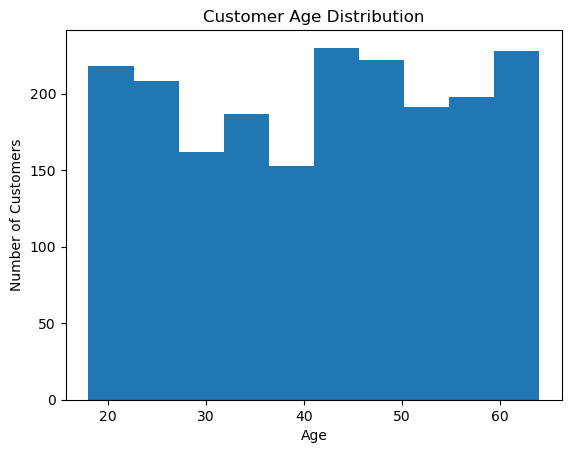

In [139]:
##What does age distribution of customers look like?
plt.hist(retail_sales["age"])
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

In [142]:
## Which product category generates the most revenue, and how do the categories compare?
category_revenue = retail_sales.groupby("category")["total_sale"].sum()
category_revenue

category
Beauty         286840.0
Clothing       311070.0
Electronics    313810.0
Name: total_sale, dtype: float64

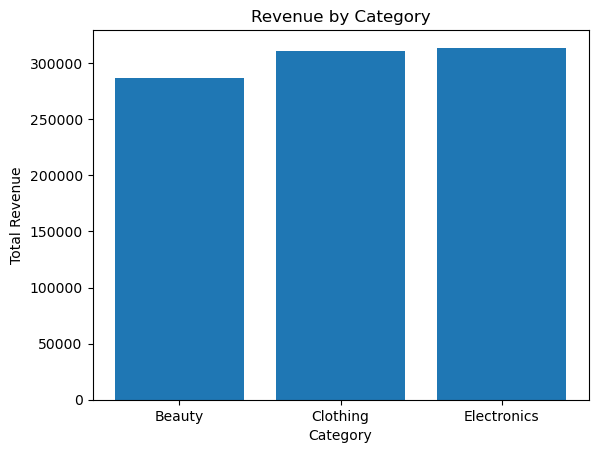

In [150]:
plt.bar(category_revenue.index, category_revenue.values)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.show()